<a href="https://colab.research.google.com/github/goutham3010/Hospital-Readmission-Prediction-System/blob/main/04_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOSPITAL READMISSION PREDICTION SYSTEM
## NOTEBOOK 04: MODEL TRAINING
This notebook trains, evaluates, and compares classification algorithms (Logistic Regression, Decision Tree, Random Forest) with stratified cross-validation and pipeline integration.


### 1. IMPORT LIBRARIES


In [10]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")


Libraries imported successfully.


### 2. LOAD DATASET


In [11]:
# ============================================================
# 2. LOAD DATASET
# ============================================================


df = pd.read_csv( "/content/hospital_readmission_dataset.csv")


print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (8000, 17)


,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


### 3. BASIC CLEANING


In [12]:
# ============================================================
# 3. BASIC CLEANING
# ============================================================

# Remove duplicates
df = df.drop_duplicates()

# Remove unnecessary / risky columns
columns_to_drop = [
    "patient_id",
    "admission_date",
    "readmission_risk_score"
]

columns_to_drop = [
    col for col in columns_to_drop
    if col in df.columns
]

df = df.drop(columns=columns_to_drop)

print("Cleaned shape:", df.shape)
print("Remaining features:", df.columns.tolist())


Cleaned shape: (8000, 14)
Remaining features: ['season', 'age', 'gender', 'region', 'primary_diagnosis', 'comorbidities_count', 'length_of_stay', 'treatment_type', 'medications_count', 'followup_visits_last_year', 'prev_readmissions', 'insurance_type', 'discharge_disposition', 'label']


### 4. SEPARATE FEATURES AND TARGET


In [13]:
# ============================================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["label"])
y = df["label"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (8000, 13)
Target shape: (8000,)


### 5. IDENTIFY FEATURE TYPES


In [14]:
# ============================================================
# 5. IDENTIFY FEATURE TYPES
# ============================================================

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical features:", numerical_features)
print("Categorical features:", categorical_features)



Numerical features: ['age', 'comorbidities_count', 'length_of_stay', 'medications_count', 'followup_visits_last_year', 'prev_readmissions']
Categorical features: ['season', 'gender', 'region', 'primary_diagnosis', 'treatment_type', 'insurance_type', 'discharge_disposition']


### 6. TRAIN / TEST SPLIT


In [15]:
# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)


Training data: (6400, 13)
Testing data : (1600, 13)


### 7. PREPROCESSING PIPELINE


In [16]:
# ============================================================
# 7. PREPROCESSING PIPELINE
# ============================================================

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline built successfully.")


Preprocessing pipeline built successfully.


### 8. DEFINE MODELS


In [17]:
# ============================================================
# 8. DEFINE MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

print(f"Configured {len(models)} baseline and ensemble models.")


Configured 3 baseline and ensemble models.


### 9. TRAIN MODELS


In [18]:
# ============================================================
# 9. TRAIN MODELS
# ============================================================

results = []

trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 60)
    print(f"TRAINING: {name}")
    print("=" * 60)

    # Combine preprocessing + model
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probabilities
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    trained_models[name] = pipeline

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )



TRAINING: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.80      0.59       363
           1       0.93      0.73      0.81      1237

    accuracy                           0.74      1600
   macro avg       0.69      0.76      0.70      1600
weighted avg       0.82      0.74      0.76      1600


TRAINING: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.80      0.53       363
           1       0.92      0.65      0.76      1237

    accuracy                           0.68      1600
   macro avg       0.66      0.72      0.65      1600
weighted avg       0.80      0.68      0.71      1600


TRAINING: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.69      0.57       363
           1       0.90      0.79      0.84      1237

    accuracy                 

### 10. MODEL COMPARISON


In [19]:
# ============================================================
# 10. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(
    results_df.round(4)
)



MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.7688,0.8959,0.7930,0.8413,0.8285
0,Logistic Regression,0.7444,0.9259,0.7276,0.8148,0.8400
1,Decision Tree,0.6812,0.9173,0.6459,0.7581,0.7996


### 11. VISUALIZE MODEL PERFORMANCE


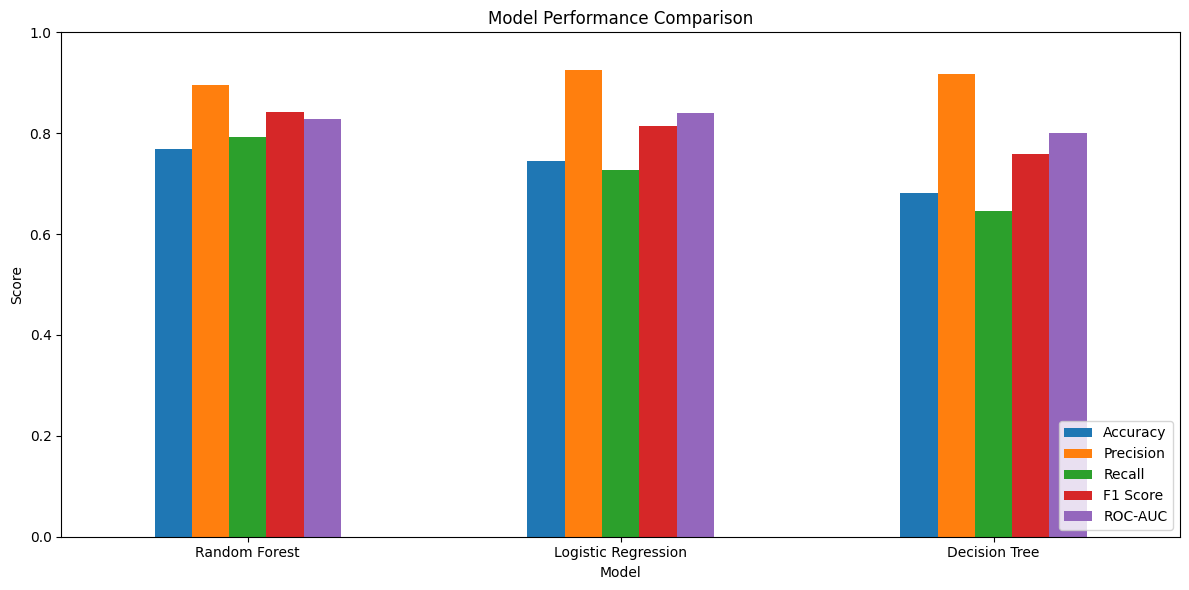

In [20]:
# ============================================================
# 11. VISUALIZE MODEL PERFORMANCE
# ============================================================

results_plot = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


### 12. SELECT BEST MODEL


In [21]:
# ============================================================
# 12. SELECT BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)

print("Selected Model:", best_model_name)



BEST MODEL
Selected Model: Random Forest


### 13. SAVE BEST MODEL


In [22]:
# ============================================================
# 13. SAVE BEST MODEL
# ============================================================

save_model_path = "best_readmission_model.pkl" if not os.path.exists("/content") else "/content/best_readmission_model.pkl"

joblib.dump(
    best_model,
    save_model_path
)

# Also save into models/ folder if available
if os.path.exists("models") or os.path.exists("../models"):
    target_dir = "models" if os.path.exists("models") else "../models"
    joblib.dump(best_model, os.path.join(target_dir, "best_readmission_model.joblib"))

print(f"\nBest model saved successfully to: {save_model_path}")



Best model saved successfully to: /content/best_readmission_model.pkl


### 14. SAVE MODEL RESULTS


In [23]:
# ============================================================
# 14. SAVE MODEL RESULTS
# ============================================================

save_csv_path = "model_comparison.csv" if not os.path.exists("/content") else "/content/model_comparison.csv"

results_df.to_csv(
    save_csv_path,
    index=False
)

print(f"Model comparison saved successfully to: {save_csv_path}")


Model comparison saved successfully to: /content/model_comparison.csv


### 15. FINAL MESSAGE


In [24]:
# ============================================================
# 15. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 60)
print("MODEL TRAINING COMPLETED")
print("=" * 60)

print("""
Models trained:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Next:
- Model Evaluation
- Confusion Matrix
- ROC Curve
- Feature Importance / SHAP
- Hyperparameter Tuning
""")



MODEL TRAINING COMPLETED

Models trained:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Next:
- Model Evaluation
- Confusion Matrix
- ROC Curve
- Feature Importance / SHAP
- Hyperparameter Tuning

